In [ ]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

In [1]:
bin_size = 0.001
seed = 42
model_conditions = {'drift_rate': 0.3, 'theta': 0.5, 'noise': 0.63}

In [ ]:
from ast import literal_eval
from temp import get_corrected_subject_empirical_distributions
from temp import generate_fixations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import simulation
import pyddm

df = pd.read_csv('../1ms_trial_data.csv')
df['RT'] = df['RT']*1000 # adjustment for RT
df['fixation'] = df['fixation'].apply(literal_eval)

sub_id = 301
sub_df = df.loc[df['sub_id'] == 301] # No dropped trials, second batch had less errors overall, more trials

odd_sub_df = sub_df.loc[sub_df['trial'] % 2 == 1]
trials = odd_sub_df[['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

sub_empirical_distributions = get_corrected_subject_empirical_distributions(sub_df)

rows = []
for idx, r in trials.iterrows():
    fx = generate_fixations(bin_size, r.avgWTP_left - r.avgWTP_right, sub_empirical_distributions)
    if fx is not None:
        rows.append((idx, fx))

trials_clean = trials.loc[[i for i, _ in rows]].copy()
trials_clean['fixation'] = [fx for _, fx in rows]
my_trials = trials_clean.to_dict(orient="records")

results_df = simulation.simulate(bin_size, model_conditions, my_trials, seed=seed, save_results=False)
results_df = results_df.drop(columns=['trajectory'])

sample = pyddm.Sample.from_pandas_dataframe(
    results_df,
    choice_column_name="choice",
    rt_column_name="RT",
    choice_names=("left", "right")
)

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_88119/2210994675.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trials['fixation'] = None
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
def drift_function(x, t, d, avgWTP_left, avgWTP_right, fixation):
    idx = min(int(t / 0.001), len(fixation) - 1)
    f = fixation[idx]
    theta = 0.5 # For theta as a constant
    if f == 0:   # no fixation
        drift_val =  0
    elif f == 1:
        drift_val = d * (avgWTP_left - theta * avgWTP_right)
    else:
        drift_val = d * (theta * avgWTP_left - avgWTP_right)
    
    return np.ones_like(x) * drift_val

def noise_function(x, t, noise):
    return np.ones_like(x) * noise

m = pyddm.gddm(
        drift=drift_function,
        noise=noise_function,
        parameters={"d": model_conditions['drift_rate'], "noise": model_conditions['noise']},
        conditions=["avgWTP_left","avgWTP_right","fixation"],
        choice_names=("left","right"),
        T_dur=10,
        dx=0.01,
        dt=0.01
)

error_m = pyddm.gddm(
        drift=drift_function,
        noise=noise_function,
        parameters={"d": 0.27, "noise": 0.66},
        conditions=["avgWTP_left","avgWTP_right","fixation"],
        choice_names=("left","right"),
        T_dur=10,
        dx=0.01,
        dt=0.01
)

In [4]:
from pyddm.models.loss import LossLikelihood

correct = []
error = []
for i in range(len(sample)):
    sample = pyddm.Sample.from_pandas_dataframe(
        pd.DataFrame(results_df.iloc[i,:]).T,
        choice_column_name="choice",
        rt_column_name="RT",
        choice_names=("left", "right")
    )

    lossfunc = LossLikelihood(sample=sample, model=m, dt=m.dt, T_dur=m.T_dur)
    correct.append(lossfunc.loss(m))
    bad_lossfunc = LossLikelihood(sample=sample, model=error_m, dt=error_m.dt, T_dur=error_m.T_dur)
    error.append(bad_lossfunc.loss(error_m))

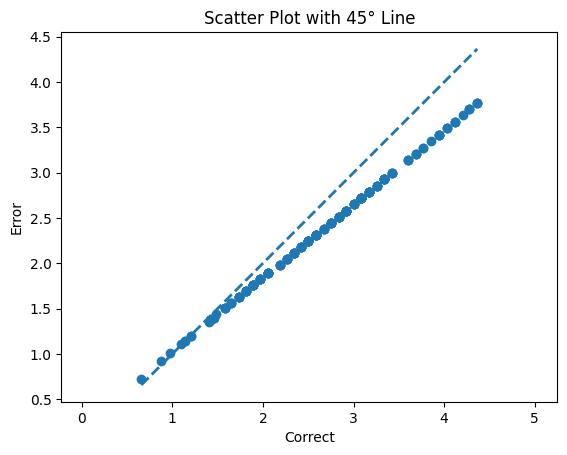

In [5]:
import matplotlib.pyplot as plt

plt.scatter(correct, error)
min_val = min(min(correct),min(error))
max_val = max(max(correct), max(error))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2)

plt.xlabel("Correct")
plt.ylabel("Error")
plt.title("Scatter Plot with 45° Line")
plt.axis("equal")  # optional: keeps aspect ratio square

plt.show()